In [1]:
using Markdown
using Printf
using Plots
using Statistics
using LinearAlgebra

In [26]:
function nested(d::Int, c::Vector{<:Real}, x::Real, xb::Vector{<:Real} = zeros(d))
    if length(c) != d + 1
        error("Must have $(d+1) constants")
    end

    if length(xb) != d
        error("Must have $(d) base points. Currently have $(length(xb)) base points.")
    end

    # string = "($(c[1]))"

    y = c[1]

    for i in 1:d
        y *= (x - xb[d - i + 1])
        y += c[i+1]
        # string = "($(c[i+1]) + (x - $(xb[d - i + 1]))" * string * ")"
    end


    return y
end

nested (generic function with 2 methods)

In [27]:
function newtonsInterpolation(x ::Vector{<:Real}, y ::Vector{<:Real}, divided_differences)
    start = length(divided_differences) == 0 ? 1 : length(divided_differences[1])

    if length(divided_differences) == 0
        push!(divided_differences, y)
    else
        divided_differences[1] = y
    end

    for i in start+1:length(x)
        push!(divided_differences, [])
    end

    curr_start = start;


    for i in 2:length(x)
        for j in curr_start:length(x) - i + 1
            divided_difference =  divided_differences[i-1][j + 1] - divided_differences[i - 1][j]
            push!(divided_differences[i], divided_difference/(x[j + i - 1] - x[j]))
        end

        if start != 1
            curr_start -= 1
        end
    end

    c = [divided_differences[length(divided_differences) - i + 1][1] for i in 1:length(divided_differences)]

    
    return divided_differences, (t::Real) -> nested(length(x) - 1, c, t, x[1: length(x) - 1])
end

newtonsInterpolation (generic function with 1 method)

In [28]:
year = [1994.0 + i for i in 0:9]
bblperday = [67.052, 68.008, 69.803, 72.024, 73.400, 72.063, 74.669, 74.487, 74.065, 76.777]

dd, nine_interpolant = newtonsInterpolation(year, bblperday, [])

(Any[[67.052, 68.008, 69.803, 72.024, 73.4, 72.063, 74.669, 74.487, 74.065, 76.777], Any[0.9559999999999889, 1.7950000000000017, 2.2210000000000036, 1.3760000000000048, -1.3370000000000033, 2.6059999999999945, -0.18200000000000216, -0.42199999999999704, 2.7120000000000033], Any[0.4195000000000064, 0.21300000000000097, -0.42249999999999943, -1.356500000000004, 1.971499999999999, -1.3939999999999984, -0.11999999999999744, 1.5670000000000002], Any[-0.06883333333333515, -0.21183333333333346, -0.31133333333333485, 1.1093333333333344, -1.1218333333333323, 0.42466666666666697, 0.5623333333333326], Any[-0.035749999999999574, -0.024875000000000348, 0.3551666666666673, -0.5577916666666667, 0.38662499999999983, 0.0344166666666664], Any[0.002174999999999845, 0.07600833333333354, -0.1825916666666668, 0.1888833333333333, -0.0704416666666667], Any[0.012305555555555616, -0.043100000000000055, 0.061912500000000016, -0.043220833333333326], Any[-0.007915079365079382, 0.015001785714285723, -0.015019047619

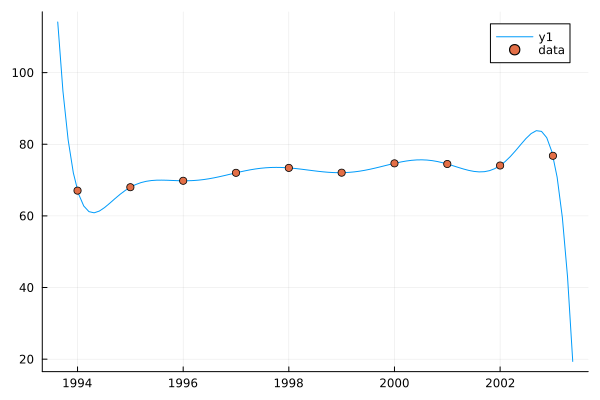

In [29]:
x = range(1993.625, 2003.375, 100)
plot(x, nine_interpolant)
plot!(year, bblperday, seriestype=:scatter, label="data")

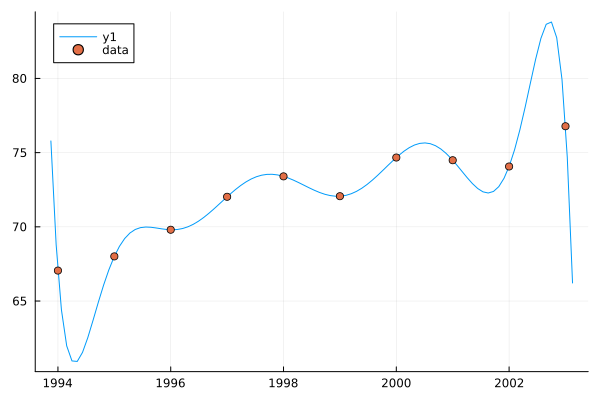

In [30]:
x = range(1993.875, 2003.125, 100)
plot(x, nine_interpolant)
plot!(year, bblperday, seriestype=:scatter, label="data")

In [73]:
estimate_2010 = nine_interpolant(2010.0)

-1.951646134000001e6

In [129]:
Markdown.parse(""" # Section 3.2: Computer Problem 3
The estimate for 2010 oil production is $(estimate_2010) bbl/day (`` \\times 10^6``).

The example has Runge's Phenomenon as you can see occilatory behavior between the equally spaced data points. Due to extreme occurance of Runge's Phenomenon between datapoints and especially near the enpoints of the interpolation range, I would say in the range between ``1993 \\leq x \\leq 2003`` occilations between data points especially between causes unexpected behavior and will most likely be innacurate. Anything even a little outside this range will exibhit even worse behavior as the interpolating polynomial quickly diverges to infinity and negative infinity. Thus the interpolating polynomial is not a good model of data.  

Estimate for 2010 is not good because extrapolating with a high degree polynomial may be problematic as they quickly diverage outside the interpolation range as seen above so we get a estimate which doesn't even make sense in the context.
    
""")

# Section 3.2: Computer Problem 3

The estimate for 2010 oil production is -1.951646134000001e6 bbl/day ($\times 10^6$).

The example has Runge's Phenomenon as you can see occilatory behavior between the equally spaced data points. Due to extreme occurance of Runge's Phenomenon between datapoints and especially near the enpoints of the interpolation range, I would say in the range between $1993 \leq x \leq 2003$ occilations between data points especially between causes unexpected behavior and will most likely be innacurate. Anything even a little outside this range will exibhit even worse behavior as the interpolating polynomial quickly diverges to infinity and negative infinity. Thus the interpolating polynomial is not a good model of data.  

Estimate for 2010 is not good because extrapolating with a high degree polynomial may be problematic as they quickly diverage outside the interpolation range as seen above so we get a estimate which doesn't even make sense in the context.


In [32]:
_ , four_interpolant = newtonsInterpolation(year[1:4], bblperday[1:4], [])

(Any[[67.052, 68.008, 69.803, 72.024], Any[0.9559999999999889, 1.7950000000000017, 2.2210000000000036], Any[0.4195000000000064, 0.21300000000000097], Any[-0.06883333333333515]], var"#18#20"{Vector{Float64}, Vector{Float64}}([1994.0, 1995.0, 1996.0, 1997.0], [-0.06883333333333515, 0.4195000000000064, 0.9559999999999889, 67.052]))

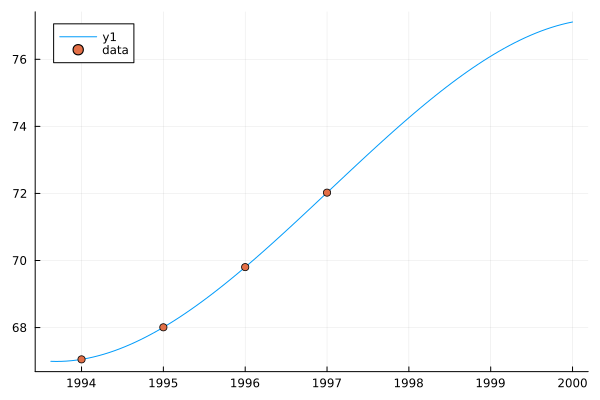

In [33]:
x = range(1993.625, 2000, 100)
plot(x, four_interpolant)
plot!(year[1:4], bblperday[1:4], seriestype=:scatter, label="data")

In [34]:
estimate_1998 = four_interpolant(1998.0)
estimate_error = abs(bblperday[5] - estimate_1998)

0.8579999999999899

In [88]:
Markdown.parse("""# Section 3.2: Computer Problem 4 
    
The estimate for 1998 oil production is $(estimate_1998) bbl/day (``\\times 10^6``).

There is not occilatory behavior between the datapoints and thus Runge's Phenomenon is not present.
""")

# Section 3.2: Computer Problem 4

The estimate for 1998 oil production is 74.258 bbl/day ($\times 10^6$).

There is not occilatory behavior between the datapoints and thus Runge's Phenomenon is not present.


In [108]:
function cubic_spline(x::Vector{<:Real}, y::Vector{<:Real}, bc="natural", v=(1,1))
    n = length(x)

    A = zeros(n, n)
    r = zeros(n, 1)

    dx = zeros(n, 1)
    dy = zeros(n, 1)

    
    for i in 1:n-1
        dx[i] = x[i+1] - x[i]
        dy[i] = y[i+1] - y[i]
    end

    for i in 2:n-1
        A[i, i - 1 : i + 1] = [dx[i - 1] 2*(dx[i-1] + dx[i]) dx[i]]
        r[i] = 3*(dy[i]/dx[i] - dy[i-1]/dx[i-1])
    end

    if bc == "natural"
        A[1,1] = 1
        A[n, n] = 1
    elseif bc == "curvature-adj"
        A[1, 1] = 2
        A[n, n] = 2
        r[1] = v[1]
        r[n] = v[2]
    elseif bc == "clamped"
        A[1, 1:2] = [2 * dx[1] dx[1]]
        r[1] = 3*(dy[1]/dx[1] - v[1])
        A[n, n-1:n] = [dx[n-1] 2*dx[n-1]]
        r[n] = 3*(v[2] - dy[n - 1]/dx[n-1])
    elseif bc == "parabola"
        A[1, 1:2] = [1 -1]
        A[n, n-1:n] = [1 -1]
    elseif bc == "not-a-knot" && n >= 4
        A[1, 1:3] = [dx[2] -(d[1] + dx[2]) dx[1]]
        A[n, n-2] = [dx[n-1] -(dx[n-2] + dx[n-1]) dx[n-2]]
    else
        error("Need Valid boundary condition")
    end


    coeff = zeros(n, 4)
    coeff[:, 4] = y
    coeff[:, 2] = A\r

    for i in 1:n-1
        coeff[i, 1] = (coeff[i + 1, 2] - coeff[i, 2])/(3 * dx[i])
        coeff[i, 3] = dy[i]/dx[i] - dx[i] * (2 * coeff[i, 2] + coeff[i + 1, 2])/3
    end

    coeff = coeff[1:n-1, 1:4]

    function spline(x_in :: Real)
        spline_index = 1
        for i in 1:n-1
            if x_in >= x[i] && x_in <= x[i+1]
                spline_index = i
                break
            end
        end

        coefficents = coeff[spline_index, :]

        xb = ones(3) * x[spline_index]

        return nested(3, coefficents, x_in, xb)
    end

    return spline
end

cubic_spline (generic function with 3 methods)

In [109]:
year11 = [1960.0, 1970.0, 1990.0, 2000.0]
population = [3039585530.0, 3707475887.0, 5281653820.0, 6079603571.0]
spline = cubic_spline(year11, population)

spline (generic function with 1 method)

In [117]:
Markdown.parse("""# Section 3.4; Computer Problem 11a

    Estimate for 1980: $(spline(1980))
    Error = $(4452584592 - spline(1980))
    Absolute Value of Error = $(abs(4452584592 - spline(1980)))
    
""")

# Section 3.4; Computer Problem 11a

```
Estimate for 1980: 4.470178717125e9
Error = -1.7594125125e7
Absolute Value of Error = 1.7594125125e7
```


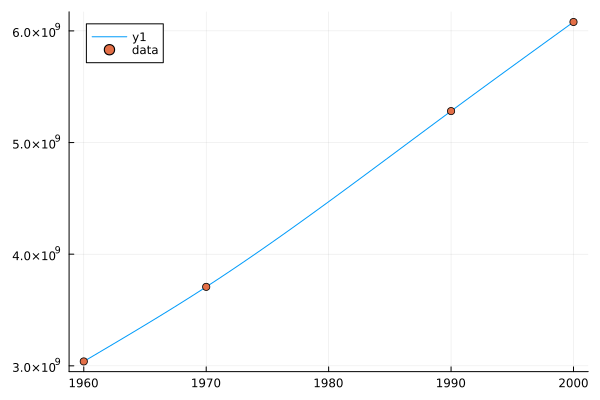

In [110]:
x = range(1960.0, 2000.0, 100)
plot(x, spline)
plot!(year11, population, seriestype=:scatter, label="data")

In [111]:
spline(1980)

4.470178717125e9

In [112]:
dx = year11[2:4] - year11[1:3]
dy = population[2:4] - population[1:3]

v = (dy[1]/dx[1], dy[3]/dx[3])

(6.67890357e7, 7.97949751e7)

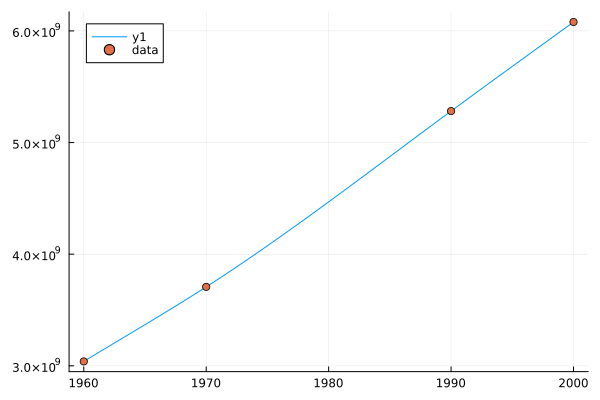

In [113]:
clamped_spline = cubic_spline(year11, population, "clamped", v)

x = range(1960.0, 2000.0, 100)
plot(x, clamped_spline)
plot!(year11, population, seriestype=:scatter, label="data")

In [126]:
Markdown.parse("""# Section 3.4; Computer Problem 11b

    Estimation with Clamped Spline

    Estimate for 1980: $(clamped_spline(1980))
    Error = $(4452584592 - clamped_spline(1980))
    Absolute Value of Error = $(abs(4452584592 - clamped_spline(1980)))

    Clamped Spline estimates better due to having a error with less magnitude. Also it seems to follow the trend of the data more closely.
""")

# Section 3.4; Computer Problem 11b

```
Estimation with Clamped Spline

Estimate for 1980: 4.4685529747e9
Error = -1.596838269999981e7
Absolute Value of Error = 1.596838269999981e7

Clamped Spline estimates better due to having a error with less magnitude. Also it seems to follow the trend of the data more closely.
```
